#### Main Insights
- 45 stores , 99 departments, 3 unique store types

- Missing markdown values(ALL markdows) for data range between 2010-02-05 and
2011-11-04
- CPI and Unemployment **both** missing between time period 2013-05-03 and
2013-07-26 
- There are patterns in missing data for markdowns, its missing at random (we simply did not had the markdowns recorded for the timeline).
- For last 3 months macroeconomic factors CPI and Unemployment both are missing. These values are probably missing because they fall into a recent/future time window where the government simply hasn't released the economic reports yet," the missingness is entirely dependent on observed data (the date). Therefore, it is MAR.


- Negative Weekly_Sales( due to returns probably)
- Negative markdowns are present.
- Some weeks have heavy markdowns (due to dicount sales probably).


#### Import necessary libraries

In [1]:
import pandas as pd
from pathlib import Path
import missingno as msno

#### Ingest
- csv's in data/raw

In [2]:
features_path = Path("../data/raw/features.csv")
sales_path = Path("../data/raw/sales.csv")
stores_path = Path("../data/raw/stores.csv")

In [3]:
features = pd.read_csv(features_path)
sales = pd.read_csv(sales_path)
stores = pd.read_csv(stores_path)

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/features.csv'

#### Rows (random samples)

In [ ]:
features.sample(10)

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
6847,38,06/04/2012,64.05,4.121,24.75,NaN,10.47,NaN,1495.97,131.037548,11.627,False
207,2,30/07/2010,83.49,2.640,NaN,NaN,NaN,NaN,NaN,211.026468,8.099,False
7472,42,16/04/2010,69.74,3.109,NaN,NaN,NaN,NaN,NaN,126.562100,9.524,False
4797,27,06/05/2011,56.48,4.192,NaN,NaN,NaN,NaN,NaN,138.413120,7.725,False
6695,37,02/11/2012,62.44,3.386,74.74,293.84,17.50,NaN,798.26,222.132141,6.228,False
6126,34,25/05/2012,72.42,3.551,4031.31,43.00,146.38,1114.59,2174.14,131.028774,9.575,False
961,6,28/01/2011,44.98,3.010,NaN,NaN,NaN,NaN,NaN,213.714341,6.858,False
2415,14,14/01/2011,24.78,3.205,NaN,NaN,NaN,NaN,NaN,182.658578,8.549,False
4190,24,05/03/2010,36.73,2.919,NaN,NaN,NaN,NaN,NaN,131.735000,8.326,False
3312,19,15/10/2010,51.32,2.999,NaN,NaN,NaN,NaN,NaN,132.763355,8.067,False


In [ ]:
sales.sample(10)

,Store,Dept,Date,Weekly_Sales,IsHoliday
180213,19,24,03/12/2010,8784.37,False
86737,9,90,13/08/2010,2384.22,False
77004,8,82,13/01/2012,11869.07,False
50460,6,12,23/12/2011,5032.28,False
249159,26,17,06/04/2012,7434.06,False
329861,34,92,12/10/2012,80943.67,False
24660,3,31,25/03/2011,870.50,False
353292,37,96,09/04/2010,19405.82,False
88310,10,6,17/06/2011,11224.46,False
170999,18,27,06/04/2012,2565.76,False


In [ ]:
stores.sample(10)

,Store,Type,Size
39,40,A,155083
3,4,A,205863
10,11,A,207499
20,21,B,140167
23,24,A,203819
22,23,B,114533
44,45,B,118221
9,10,B,126512
27,28,A,206302
11,12,B,112238


#### Duplicates
- None found

In [ ]:
features[features.duplicated()]

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday


In [ ]:
stores[stores.duplicated()]

,Store,Type,Size


In [ ]:
sales[sales.duplicated()]

,Store,Dept,Date,Weekly_Sales,IsHoliday


#### Sorting by Date


In [ ]:
features = features.sort_values(by='Date', ascending=True)
sales = sales.sort_values(by='Date', ascending=True)

#### Column Info

In [ ]:
features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8190 entries, 7436 to 4051
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 775.8+ KB


In [ ]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
Index: 421570 entries, 381747 to 58006
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 16.5+ MB


In [ ]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB


#### Missing Values
- Missing markdown values(ALL markdows) for data range between 2010-02-05 and
2011-11-04
- CPI and Unemployment **both** missing between time period 2013-05-03 and
2013-07-26 
- There are patterns in missing data for markdowns, its missing at random (we simply did not had the markdowns recorded for the timeline).
- For last 3 months macroeconomic factors CPI and Unemployment both are missing. These values are probably missing because they fall into a recent/future time window where the government simply hasn't released the economic reports yet," the missingness is entirely dependent on observed data (the date). Therefore, it is MAR.


In [ ]:
# features.isnull().sum()

In [ ]:
features.isna().mean() * 100

Store            0.000000
Date             0.000000
Temperature      0.000000
Fuel_Price       0.000000
MarkDown1       50.769231
MarkDown2       64.334554
MarkDown3       55.885226
MarkDown4       57.704518
MarkDown5       50.549451
CPI              7.142857
Unemployment     7.142857
IsHoliday        0.000000
dtype: float64

In [ ]:
stores.isna().mean()*100

Store    0.0
Type     0.0
Size     0.0
dtype: float64

In [ ]:
sales.isna().mean()*100

Store           0.0
Dept            0.0
Date            0.0
Weekly_Sales    0.0
IsHoliday       0.0
dtype: float64

<Axes: >

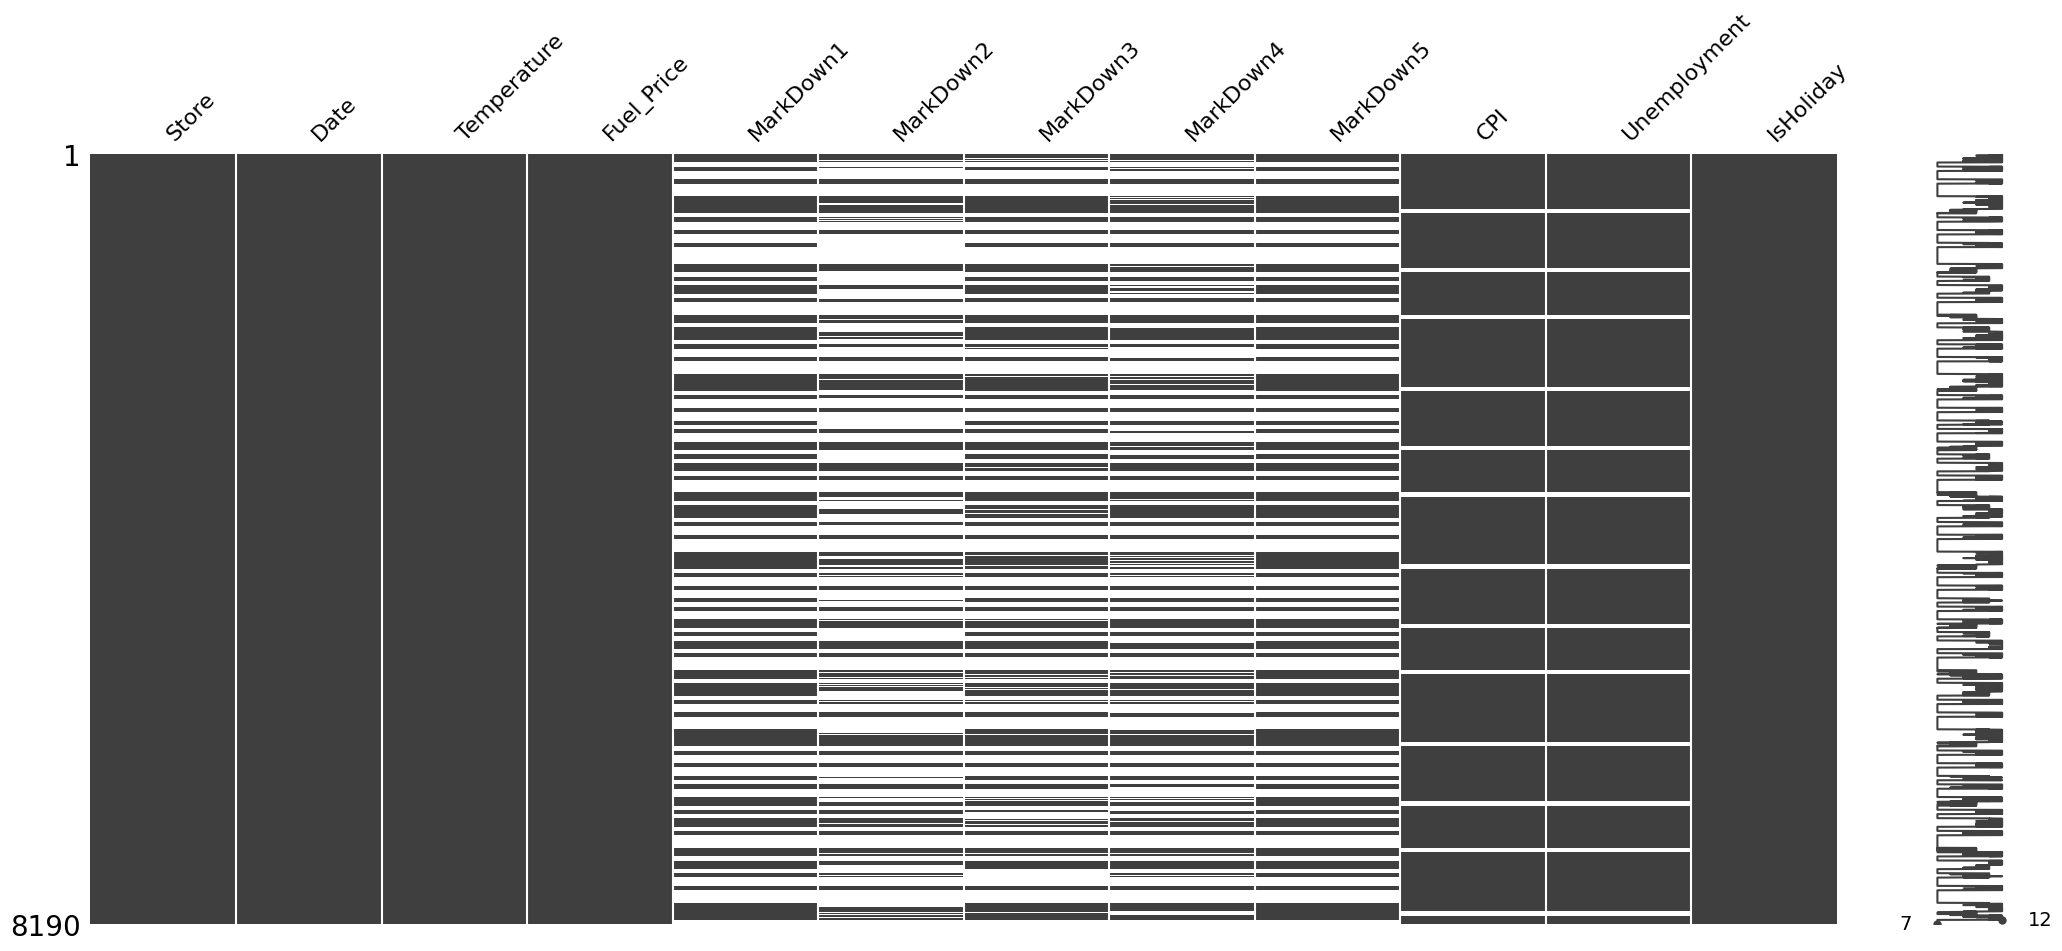

In [ ]:
msno.matrix(features)

In [ ]:
null_rows = features[features['MarkDown1'].isna() & 
                            features['MarkDown2'].isna() & 
                            features['MarkDown3'].isna() & 
                            features['MarkDown4'].isna() & 
                            features['MarkDown5'].isna() ]
print(null_rows['Date'].min())
print(null_rows['Date'].max())


01/04/2011
31/12/2010


In [ ]:
null_cpi_unem = features[features['CPI'].isna() & features['Unemployment'].isna()]
null_cpi_unem.sample(5)

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
7999,44,31/05/2013,60.51,3.773,468.80,NaN,5.29,NaN,1340.18,NaN,NaN,False
6731,37,12/07/2013,84.02,3.400,75.65,17.79,8.47,NaN,1264.00,NaN,NaN,False
7092,39,21/06/2013,84.67,3.479,24462.35,520.05,242.32,12723.81,45050.55,NaN,NaN,False
2722,15,07/06/2013,62.21,3.792,7883.89,1378.88,120.00,2637.43,3925.20,NaN,NaN,False
4361,24,14/06/2013,63.33,3.795,5291.57,642.43,607.93,3835.43,3738.93,NaN,NaN,False


In [ ]:
print(null_cpi_unem['Date'].min())
print(null_cpi_unem['Date'].max())

03/05/2013
31/05/2013


<Axes: >

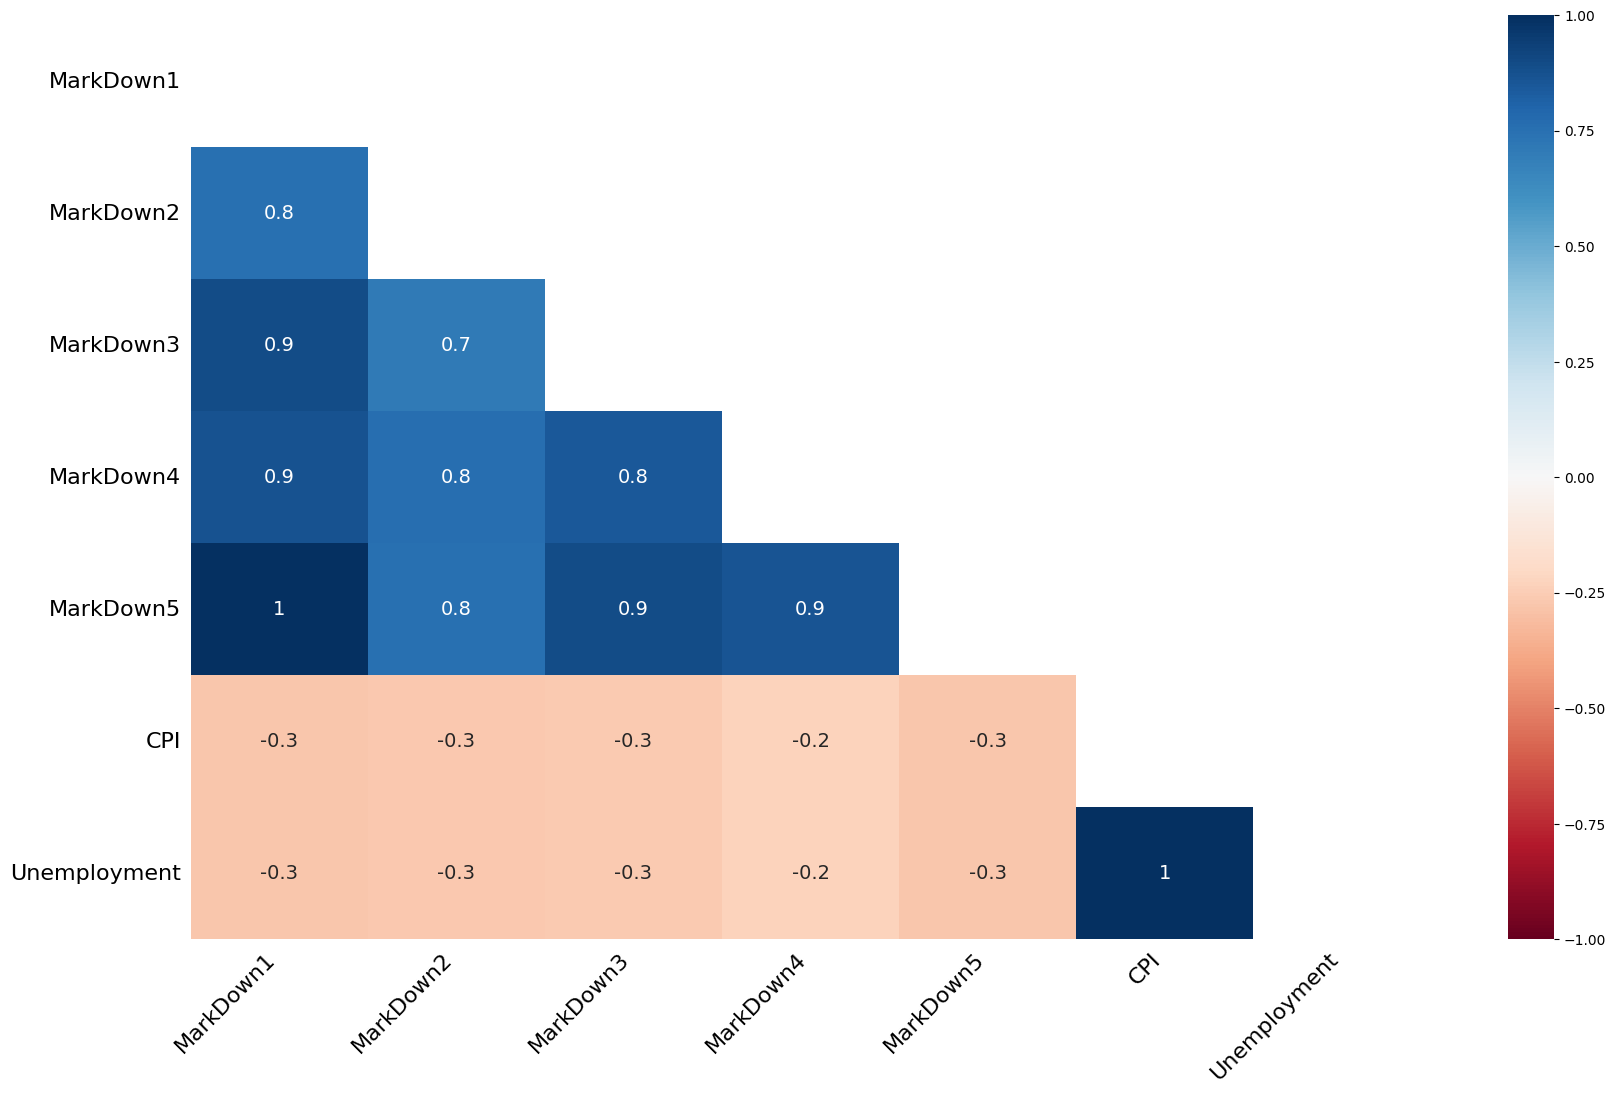

In [ ]:
msno.heatmap(features)

<Axes: >

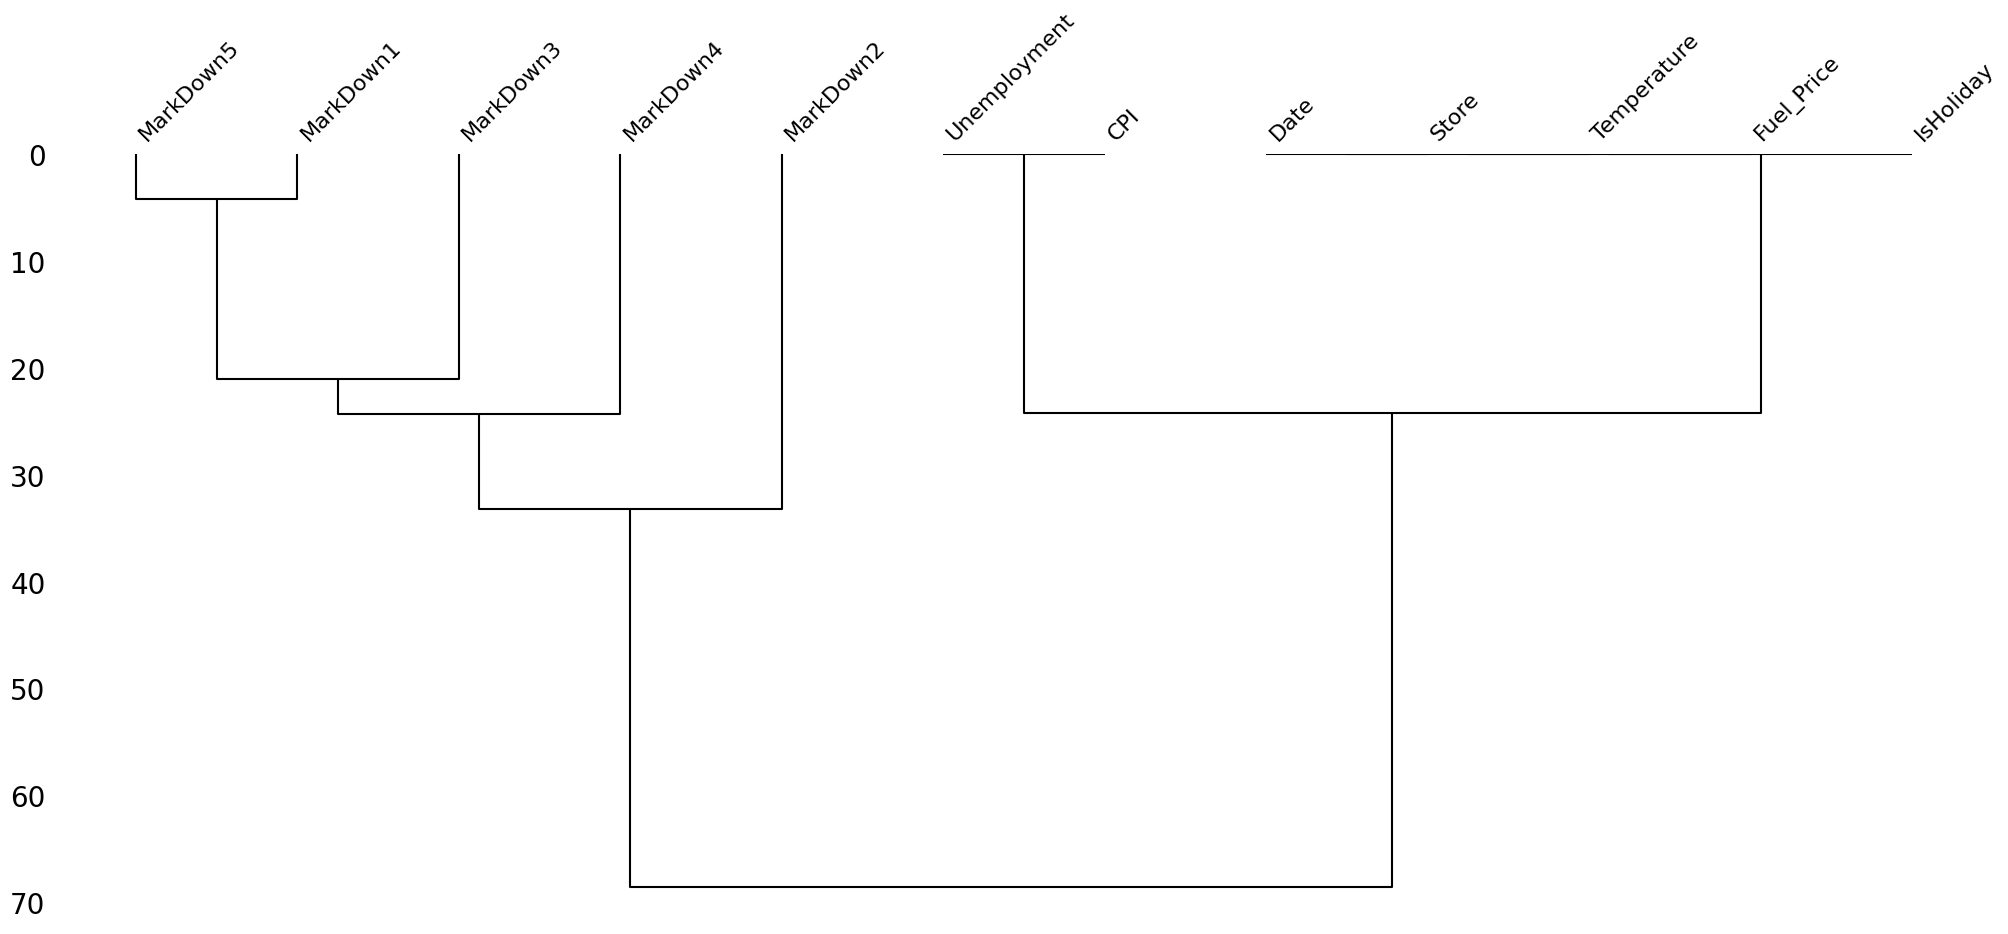

In [ ]:
msno.dendrogram(features)

#### Datetime conversion

In [ ]:
features['Date'] = pd.to_datetime(features['Date'], format='%d/%m/%Y')
sales['Date'] = pd.to_datetime(sales['Date'], format='%d/%m/%Y')

In [ ]:
print(features['Date'].sample())
print(features['Date'].sample())

7191   2011-11-18
Name: Date, dtype: datetime64[ns]
4138   2012-08-31
Name: Date, dtype: datetime64[ns]


#### 5 number summary

- Negative Weekly_Sales( due to returns probably)
- Negative markdowns are present.
- Some weeks have heavy markdowns (due to dicount sales probably).


In [ ]:
features.describe()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
count,8190.000000,8190,8190.000000,8190.000000,4032.000000,2921.000000,3613.000000,3464.000000,4050.000000,7605.000000,7605.000000
mean,23.000000,2011-10-31 12:00:00,59.356198,3.405992,7032.371786,3384.176594,1760.100180,3292.935886,4132.216422,172.460809,7.826821
min,1.000000,2010-02-05 00:00:00,-7.290000,2.472000,-2781.450000,-265.760000,-179.260000,0.220000,-185.170000,126.064000,3.684000
25%,12.000000,2010-12-17 00:00:00,45.902500,3.041000,1577.532500,68.880000,6.600000,304.687500,1440.827500,132.364839,6.634000
50%,23.000000,2011-10-31 12:00:00,60.710000,3.513000,4743.580000,364.570000,36.260000,1176.425000,2727.135000,182.764003,7.806000
75%,34.000000,2012-09-14 00:00:00,73.880000,3.743000,8923.310000,2153.350000,163.150000,3310.007500,4832.555000,213.932412,8.567000
max,45.000000,2013-07-26 00:00:00,101.950000,4.468000,103184.980000,104519.540000,149483.310000,67474.850000,771448.100000,228.976456,14.313000
std,12.987966,NaN,18.678607,0.431337,9262.747448,8793.583016,11276.462208,6792.329861,13086.690278,39.738346,1.877259


In [ ]:
sales.describe()

,Store,Dept,Date,Weekly_Sales
count,421570.000000,421570.000000,421570,421570.000000
mean,22.200546,44.260317,2011-06-18 08:30:31.963375360,15981.258123
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000
std,12.785297,30.492054,NaN,22711.183519


In [ ]:
stores.describe()

,Store,Size
count,45.000000,45.000000
mean,23.000000,130287.600000
std,13.133926,63825.271991
min,1.000000,34875.000000
25%,12.000000,70713.000000
50%,23.000000,126512.000000
75%,34.000000,202307.000000
max,45.000000,219622.000000


In [ ]:
stores.describe(include='object')

,Type
count,45
unique,3
top,A
freq,22
